In [1]:
# ==============================================================================
# CELL 1: DATA PREPARATION & TRAINING (STANDARD SPLIT)
# ==============================================================================
import xarray as xr
import numpy as np
import pandas as pd  # Added Pandas for datetime formatting
import regionmask
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import ConvLSTM2D, BatchNormalization, Conv2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import gc

print(f"\n{'='*80}\n   1. LOADING DATA & DOWNSAMPLING GRID (61x61)\n{'='*80}")
file_path = '/Users/ghosh/OneDrive/Documents/Year 4/Final project/final10.nc'
features = ['stl4', 'lmlt', 't2m', 'sp', 'tp', 'str', 'd2m', 'strd', 'swvl1', 'swvl3']                                            
accum_vars = ['tp', 'str', 'strd']

ds = xr.open_dataset(file_path)
if 'latitude' in ds.coords:
    ds = ds.rename({'longitude': 'lon', 'latitude': 'lat'})

uk_box = ds.sel(lat=slice(61, 49, 2), lon=slice(-10, 2, 2))
countries = regionmask.defined_regions.natural_earth_v5_0_0.countries_110
uk_mask = countries.mask(uk_box['lon'], uk_box['lat']) == countries.names.index('United Kingdom')
uk_masked = uk_box.where(uk_mask)

time_coord = 'valid_time' if 'valid_time' in uk_masked.coords else list(uk_masked.coords)[0]
days = uk_masked[time_coord].dt.days_in_month
days_3d = days.broadcast_like(uk_masked['t2m'])

processed_das = []
for v in features:
    da = uk_masked[v]
    if v in accum_vars:
        monthly_da = (da * days_3d).resample({time_coord: '1ME'}).sum(skipna=False)
        if v == 'tp': monthly_da *= 1000.0  
    else:
        monthly_da = da.resample({time_coord: '1ME'}).mean()
        if v in ['stl4', 'lmlt', 't2m', 'd2m']: monthly_da -= 273.15  
    monthly_da.name = v
    processed_das.append(monthly_da.astype(np.float32))

ds_monthly = xr.merge(processed_das).sel({time_coord: slice(None, '2021-12-31')})
del ds, uk_box, uk_masked
gc.collect()

print(f"\n{'='*80}\n   2. BULLETPROOF SCALING & 5D TENSOR\n{'='*80}")
target_feature = 't2m'
target_idx = features.index(target_feature)
data_4d = np.stack([ds_monthly[var].values for var in features], axis=-1)

data_scaled = np.zeros_like(data_4d, dtype=np.float32)                                                                        
scalers = {} 
static_land_mask = ~np.isnan(data_4d[0, ..., 0])

lookback = 12 
total_sequences = data_4d.shape[0] - lookback
train_split = int(total_sequences * 0.70)
train_end_idx = train_split + lookback 

for i, feature in enumerate(features):
    train_pixels = data_4d[:train_end_idx, ..., i][:, static_land_mask]
    mean_val = np.nanmean(train_pixels)
    std_val = np.nanstd(train_pixels)
    scalers[feature] = {'mean': mean_val, 'std': std_val}
    data_scaled[..., i] = (data_4d[..., i] - mean_val) / (std_val + 1e-8)

data_scaled = np.nan_to_num(data_scaled, nan=0.0)
del data_4d
gc.collect()

X, y = [], []
for i in range(data_scaled.shape[0] - lookback):
    X.append(data_scaled[i : i + lookback])
    y.append(data_scaled[i + lookback, ..., target_idx : target_idx + 1])
X, y = np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

print(f"\n{'='*80}\n   3. STANDARD CHRONOLOGICAL SPLIT & TIMELINES\n{'='*80}")
val_split = int(X.shape[0] * 0.85)

# The physical split
X_train, y_train = X[:train_split], y[:train_split]
X_val, y_val = X[train_split:val_split], y[train_split:val_split]
X_test, y_test = X[val_split:], y[val_split:]

# --- NEW: PRINTING THE TIMELINES ---
times = pd.to_datetime(ds_monthly[time_coord].values)
target_times = times[lookback:] # The targets start after the 12-month lookback

train_times = target_times[:train_split]
val_times = target_times[train_split:val_split]
test_times = target_times[val_split:]

print(f" TRAINING SET   : {train_times[0].strftime('%b %Y')} to {train_times[-1].strftime('%b %Y')} ({len(train_times)} months)")
print(f" VALIDATION SET : {val_times[0].strftime('%b %Y')} to {val_times[-1].strftime('%b %Y')} ({len(val_times)} months)")
print(f" TESTING SET    : {test_times[0].strftime('%b %Y')} to {test_times[-1].strftime('%b %Y')} ({len(test_times)} months)")
print(f"    -> Datasets are perfectly back-to-back (No Embargo Gap applied).")
# -----------------------------------

del data_scaled, X, y
gc.collect()

print(f"\n{'='*80}\n   4. SMART TRAINING (WITH SCHEDULER)\n{'='*80}")
_, time_steps, n_lat, n_lon, n_features = X_train.shape
model = Sequential([
    ConvLSTM2D(32, (3, 3), padding='same', return_sequences=True, input_shape=(time_steps, n_lat, n_lon, n_features)),
    BatchNormalization(),
    ConvLSTM2D(32, (3, 3), padding='same', return_sequences=True),
    BatchNormalization(),
    ConvLSTM2D(16, (3, 3), padding='same', return_sequences=False),
    BatchNormalization(),
    Conv2D(1, (3, 3), activation='linear', padding='same')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('best_thesis_convlstm.keras', monitor='val_loss', save_best_only=True, verbose=1)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)

history = model.fit(
    X_train, y_train, epochs=25, batch_size=2, validation_data=(X_val, y_val),
    callbacks=[early_stop, checkpoint, lr_scheduler], verbose=1
)

C:\Users\ghosh\anaconda3\envs\climate\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(



   1. LOADING DATA & DOWNSAMPLING GRID (61x61)

   2. BULLETPROOF SCALING & 5D TENSOR

   3. STANDARD CHRONOLOGICAL SPLIT & TIMELINES
 TRAINING SET   : Jan 1951 to Aug 2000 (596 months)
 VALIDATION SET : Sep 2000 to Apr 2011 (128 months)
 TESTING SET    : May 2011 to Dec 2021 (128 months)
    -> Datasets are perfectly back-to-back (No Embargo Gap applied).

   4. SMART TRAINING (WITH SCHEDULER)


C:\Users\ghosh\anaconda3\envs\climate\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/25
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - loss: 0.2735 - mae: 0.3035
Epoch 1: val_loss improved from None to 0.06311, saving model to best_thesis_convlstm.keras

Epoch 1: finished saving model to best_thesis_convlstm.keras
298/298 ━━━━━━━━━━━━━━━━━━━━ 147s 449ms/step - loss: 0.1245 - mae: 0.2175 - val_loss: 0.0631 - val_mae: 0.1250 - learning_rate: 0.0010
Epoch 2/25
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - loss: 0.0566 - mae: 0.1578
Epoch 2: val_loss improved from 0.06311 to 0.02850, saving model to best_thesis_convlstm.keras

Epoch 2: finished saving model to best_thesis_convlstm.keras
298/298 ━━━━━━━━━━━━━━━━━━━━ 130s 437ms/step - loss: 0.0495 - mae: 0.1476 - val_loss: 0.0285 - val_mae: 0.0973 - learning_rate: 0.0010
Epoch 3/25
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - loss: 0.0395 - mae: 0.1296
Epoch 3: val_loss did not improve from 0.02850
298/298 ━━━━━━━━━━━━━━━━━━━━ 125s 420ms/step - loss: 0.0395 - mae: 0.1284 - val_loss: 0.0702 - val_mae: 0.1695 - learning_r

In [21]:
# Calculate the exact number of grid cells
total_pixels = 61 * 61
land_pixels = np.sum(static_land_mask)
ocean_pixels = total_pixels - land_pixels

print(f"Total Grid Cells (61x61 bounding box) : {total_pixels:,}")
print(f"Active UK Land Cells (targets)     : {land_pixels:,}")
print(f"Masked Ocean Cells (Ignored)    : {ocean_pixels:,}")

Total Grid Cells (61x61 bounding box) : 3,721
Active UK Land Cells (targets)     : 778
Masked Ocean Cells (Ignored)    : 2,943



   GENERATING LEARNING CURVE


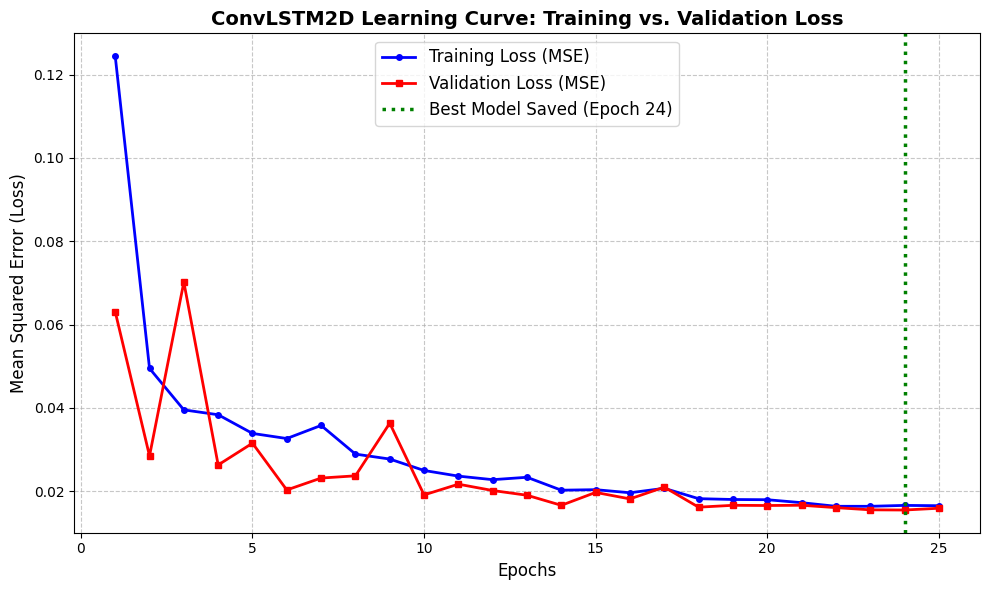

In [15]:
# ==============================================================================
# TRAINING VS VALIDATION LOSS (LEARNING CURVE)
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np

print(f"\n{'='*70}\n   GENERATING LEARNING CURVE\n{'='*70}")

# 1. Extract the loss data dynamically from memory
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# 2. Count exactly how many epochs it ran
epochs_run = range(1, len(train_loss) + 1)

# 3. Create the plot
plt.figure(figsize=(10, 6))
plt.plot(epochs_run, train_loss, label='Training Loss (MSE)', color='blue', linewidth=2, marker='o', markersize=4)
plt.plot(epochs_run, val_loss, label='Validation Loss (MSE)', color='red', linewidth=2, marker='s', markersize=4)

# 4. Automatically find and highlight the best epoch 
best_epoch = np.argmin(val_loss) + 1
plt.axvline(x=best_epoch, color='green', linestyle=':', linewidth=2.5, 
            label=f'Best Model Saved (Epoch {best_epoch})')

# 5. Format the graph 
plt.title('ConvLSTM2D Learning Curve: Training vs. Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Mean Squared Error (Loss)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Legend will now automatically include the Best Epoch line
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

   5. LOADING MODEL & FORECASTING
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step

 > FINAL THESIS RESULTS:
   - Test MAE: 1.10 °C
   - Test R²:  0.91

   6. VISUALISING GRAPHS


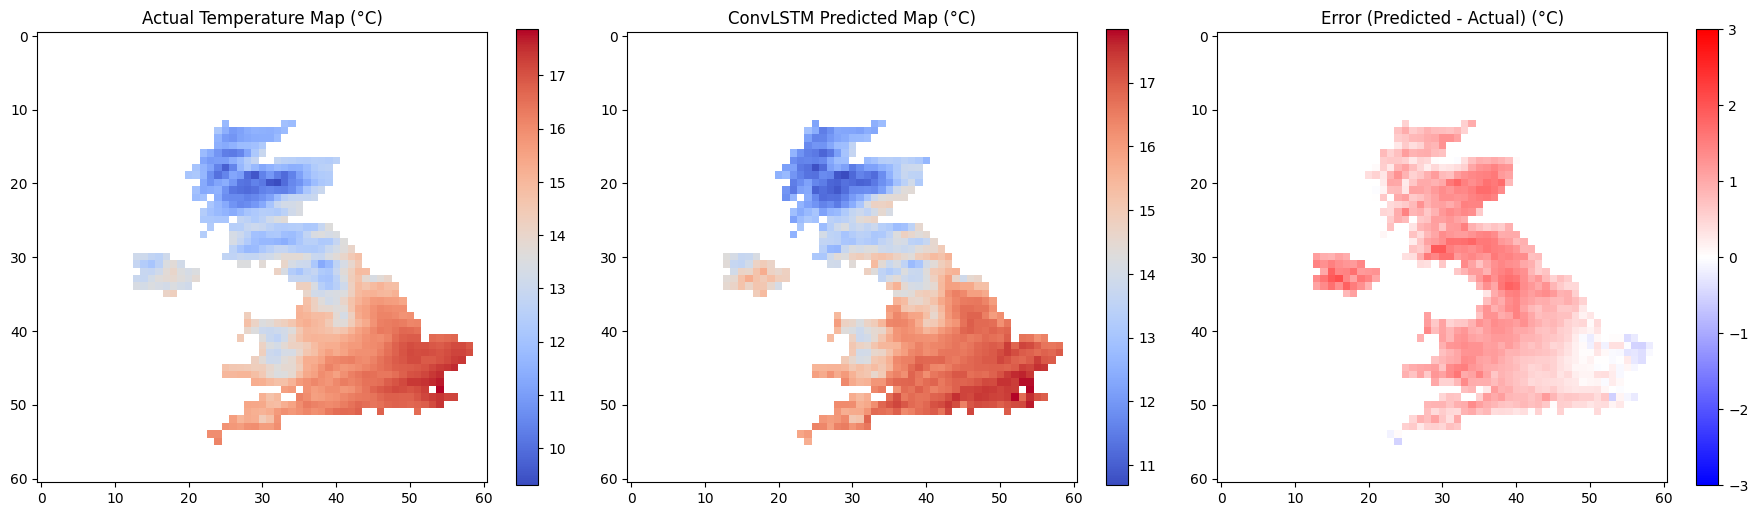

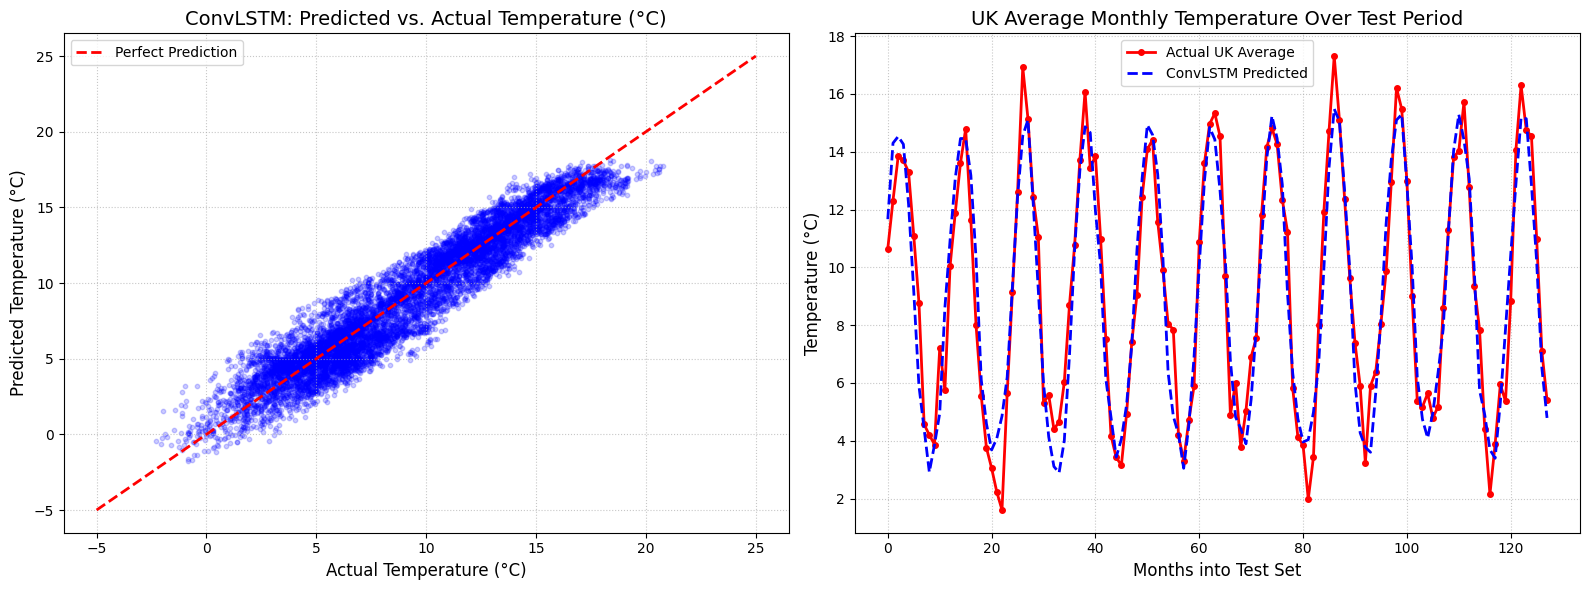

In [16]:
# ==============================================================================
# CELL 2: FORECASTING & THESIS VISUALIZATIONS
# ==============================================================================
from tensorflow.keras.models import load_model
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np

print(f"{'='*80}\n   5. LOADING MODEL & FORECASTING\n{'='*80}")
model = load_model('best_thesis_convlstm.keras') 
raw_predictions = model.predict(X_test)

t2m_mean = scalers[target_feature]['mean']
t2m_std = scalers[target_feature]['std']

y_test_celsius = (y_test * t2m_std) + t2m_mean
predictions_celsius = (raw_predictions * t2m_std) + t2m_mean

land_mask_2d = static_land_mask
y_true_flat = y_test_celsius[:, land_mask_2d, 0].flatten()
y_pred_flat = predictions_celsius[:, land_mask_2d, 0].flatten()

final_mae = mean_absolute_error(y_true_flat, y_pred_flat)
final_r2 = r2_score(y_true_flat, y_pred_flat)

print(f"\n > FINAL THESIS RESULTS:")
print(f"   - Test MAE: {final_mae:.2f} °C")
print(f"   - Test R²:  {final_r2:.2f}")

print(f"\n{'='*80}\n   6. VISUALISING GRAPHS\n{'='*80}")
# --- GRAPH 1: THE UK MAPS ---
time_idx = 50 
true_map = y_test_celsius[time_idx, :, :, 0].copy()
pred_map = predictions_celsius[time_idx, :, :, 0].copy()

true_map[~land_mask_2d] = np.nan
pred_map[~land_mask_2d] = np.nan
error_map = pred_map - true_map

fig1, axes = plt.subplots(1, 3, figsize=(18, 5))
im1 = axes[0].imshow(true_map, cmap='coolwarm', origin='upper')
axes[0].set_title('Actual Temperature Map (°C)')
fig1.colorbar(im1, ax=axes[0])
im2 = axes[1].imshow(pred_map, cmap='coolwarm', origin='upper')
axes[1].set_title('ConvLSTM Predicted Map (°C)')
fig1.colorbar(im2, ax=axes[1])
im3 = axes[2].imshow(error_map, cmap='bwr', origin='upper', vmin=-3, vmax=3)
axes[2].set_title('Error (Predicted - Actual) (°C)')
fig1.colorbar(im3, ax=axes[2])
plt.tight_layout()
plt.show()

# --- GRAPH 2: SCATTER & TIME-SERIES ---
np.random.seed(42)
sample_indices = np.random.choice(len(y_true_flat), size=10000, replace=False)
y_true_sample = y_true_flat[sample_indices]
y_pred_sample = y_pred_flat[sample_indices]

fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.scatter(y_true_sample, y_pred_sample, alpha=0.2, color='blue', s=10)
ax1.plot([-5, 25], [-5, 25], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')
ax1.set_title('ConvLSTM: Predicted vs. Actual Temperature (°C)', fontsize=14)
ax1.set_xlabel('Actual Temperature (°C)', fontsize=12)
ax1.set_ylabel('Predicted Temperature (°C)', fontsize=12)
ax1.grid(True, linestyle=':', alpha=0.7)
ax1.legend()

uk_mean_true = np.nanmean(y_test_celsius[:, land_mask_2d, 0], axis=1)
uk_mean_pred = np.nanmean(predictions_celsius[:, land_mask_2d, 0], axis=1)
months = np.arange(len(uk_mean_true))

ax2.plot(months, uk_mean_true, color='red', linewidth=2, label='Actual UK Average', marker='o', markersize=4)
ax2.plot(months, uk_mean_pred, color='blue', linewidth=2, label='ConvLSTM Predicted', linestyle='--')
ax2.set_title('UK Average Monthly Temperature Over Test Period', fontsize=14)
ax2.set_xlabel('Months into Test Set', fontsize=12)
ax2.set_ylabel('Temperature (°C)', fontsize=12)
ax2.grid(True, linestyle=':', alpha=0.7)
ax2.legend()

plt.tight_layout()
plt.show()


   ISOLATING THE 2021 FORECAST
 > 2021 SPECIFIC RESULTS:
   - 2021 MAE: 1.12 °C
   - 2021 R²:  0.92


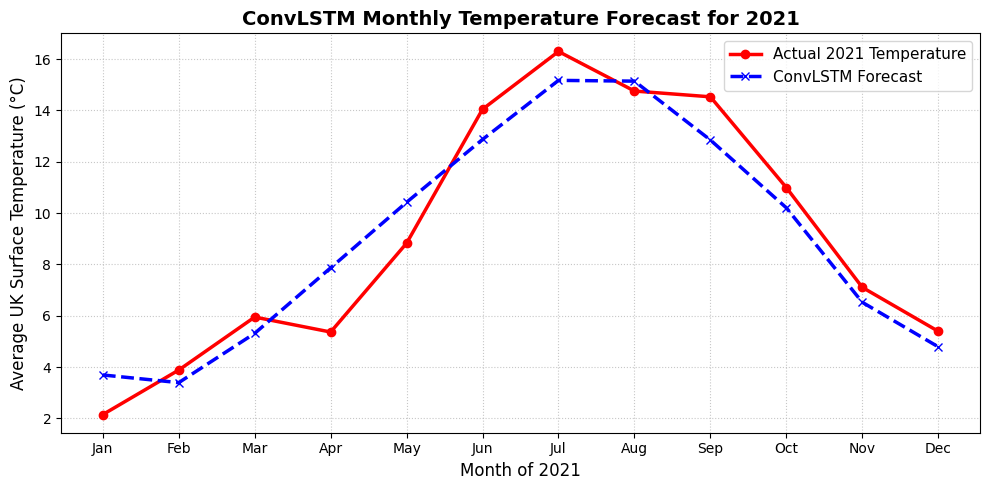

In [17]:
# ==============================================================================
# 7. CASE STUDY: THE 2021 FORECAST
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error

print(f"\n{'='*80}\n   ISOLATING THE 2021 FORECAST\n{'='*80}")

# 1. Slice the last 12 months off the test arrays (Jan 2021 - Dec 2021)
y_true_2021 = y_test_celsius[-12:, :, :, 0].copy()
y_pred_2021 = predictions_celsius[-12:, :, :, 0].copy()

# 2. Calculate the specific metrics for just 2021 (Land pixels only)
y_true_2021_flat = y_true_2021[:, land_mask_2d].flatten()
y_pred_2021_flat = y_pred_2021[:, land_mask_2d].flatten()

mae_2021 = mean_absolute_error(y_true_2021_flat, y_pred_2021_flat)
r2_2021 = r2_score(y_true_2021_flat, y_pred_2021_flat)

print(f" > 2021 SPECIFIC RESULTS:")
print(f"   - 2021 MAE: {mae_2021:.2f} °C")
print(f"   - 2021 R²:  {r2_2021:.2f}")

# 3. Calculate the monthly UK averages for the graph
uk_mean_2021_true = np.nanmean(y_true_2021[:, land_mask_2d], axis=1)
uk_mean_2021_pred = np.nanmean(y_pred_2021[:, land_mask_2d], axis=1)

# 4. Draw the 2021 Time-Series Graph
months_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(10, 5))
plt.plot(months_labels, uk_mean_2021_true, color='red', linewidth=2.5, label='Actual 2021 Temperature', marker='o')
plt.plot(months_labels, uk_mean_2021_pred, color='blue', linewidth=2.5, label='ConvLSTM Forecast', linestyle='--', marker='x')

plt.title('ConvLSTM Monthly Temperature Forecast for 2021', fontsize=14, fontweight='bold')
plt.xlabel('Month of 2021', fontsize=12)
plt.ylabel('Average UK Surface Temperature (°C)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [18]:
# ==============================================================================
# 8. PERFORMANCE OVER DIFFERENT FORECAST PERIODS
# ==============================================================================
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print(f"\n{'='*70}\n   GENERATING TABLE: FORECAST PERIOD PERFORMANCE\n{'='*70}")

# Helper function to calculate all three metrics safely
def calculate_metrics(y_true, y_pred, mask):
    # Flatten and isolate only the land pixels
    true_flat = y_true[:, mask].flatten()
    pred_flat = y_pred[:, mask].flatten()
    
    # Calculate R2, MAE, and RMSE
    r2 = r2_score(true_flat, pred_flat)
    mae = mean_absolute_error(true_flat, pred_flat)
    rmse = np.sqrt(mean_squared_error(true_flat, pred_flat))
    
    return r2, mae, rmse

# 1. Slice the time periods (Test Set ends Dec 2021)
# 2 Years (Last 24 months: Jan 2020 - Dec 2021)
true_2yr = y_test_celsius[-24:, :, :, 0]
pred_2yr = predictions_celsius[-24:, :, :, 0]

# 5 Years (Last 60 months: Jan 2017 - Dec 2021)
true_5yr = y_test_celsius[-60:, :, :, 0]
pred_5yr = predictions_celsius[-60:, :, :, 0]

# ~10 Years (All months of Test Set: May 2012 - Dec 2021)
true_10yr = y_test_celsius[:, :, :, 0]
pred_10yr = predictions_celsius[:, :, :, 0]

# 2. Calculate the metrics for each period
r2_2, mae_2, rmse_2 = calculate_metrics(true_2yr, pred_2yr, land_mask_2d)
r2_5, mae_5, rmse_5 = calculate_metrics(true_5yr, pred_5yr, land_mask_2d)
r2_10, mae_10, rmse_10 = calculate_metrics(true_10yr, pred_10yr, land_mask_2d)

# 3. Print the table
print(f"{'Forecast Period':<25} | {'R²':<6} | {'MAE (°C)':<8} | {'RMSE (°C)':<9}")
print("-" * 57)
print(f"{'2 years (2020-2021)':<25} | {r2_2:.2f}   | {mae_2:.2f}     | {rmse_2:.2f}")
print(f"{'5 years (2017-2021)':<25} | {r2_5:.2f}   | {mae_5:.2f}     | {rmse_5:.2f}")
print(f"{'10 years (2012-2021)':<25} | {r2_10:.2f}   | {mae_10:.2f}     | {rmse_10:.2f}")
print("-" * 57)


   GENERATING TABLE: FORECAST PERIOD PERFORMANCE
Forecast Period           | R²     | MAE (°C) | RMSE (°C)
---------------------------------------------------------
2 years (2020-2021)       | 0.92   | 1.03     | 1.25
5 years (2017-2021)       | 0.93   | 1.02     | 1.25
10 years (2012-2021)      | 0.91   | 1.10     | 1.36
---------------------------------------------------------


In [19]:
# ==============================================================================
# 8.5 ISOLATING THE EXTREME HEATWAVE FOR THE STRESS TEST
# ==============================================================================
print(f"\n{'='*80}\n   STRESS TEST: LOCATING THE HOTTEST MONTH\n{'='*80}")

# 1. Find the month with the highest maximum temperature on the UK landmass
# (We take the max across the active land pixels for each month)
uk_max_temps = np.nanmax(y_test_celsius[:, land_mask_2d, 0], axis=1)
hottest_idx = np.argmax(uk_max_temps)

# 2. Get the date (using test_times from Cell 1)
hottest_date = test_times[hottest_idx].strftime('%B %Y')
print(f" > Extreme Heatwave Detected: {hottest_date} (Test Set Index {hottest_idx})")
print(f" > Peak Temperature: {uk_max_temps[hottest_idx]:.2f} °C")

# 3. Extract the 2D spatial maps for that specific month
actual_heatwave = y_test_celsius[hottest_idx, :, :, 0].copy()
predicted_heatwave = predictions_celsius[hottest_idx, :, :, 0].copy()

# 4. Apply the land mask (set the ocean to NaN so it doesn't ruin the color scales)
actual_heatwave[~land_mask_2d] = np.nan
predicted_heatwave[~land_mask_2d] = np.nan

# 5. Calculate the specific error for the heatwave
difference_map = predicted_heatwave - actual_heatwave


   STRESS TEST: LOCATING THE HOTTEST MONTH
 > Extreme Heatwave Detected: July 2018 (Test Set Index 86)
 > Peak Temperature: 21.08 °C


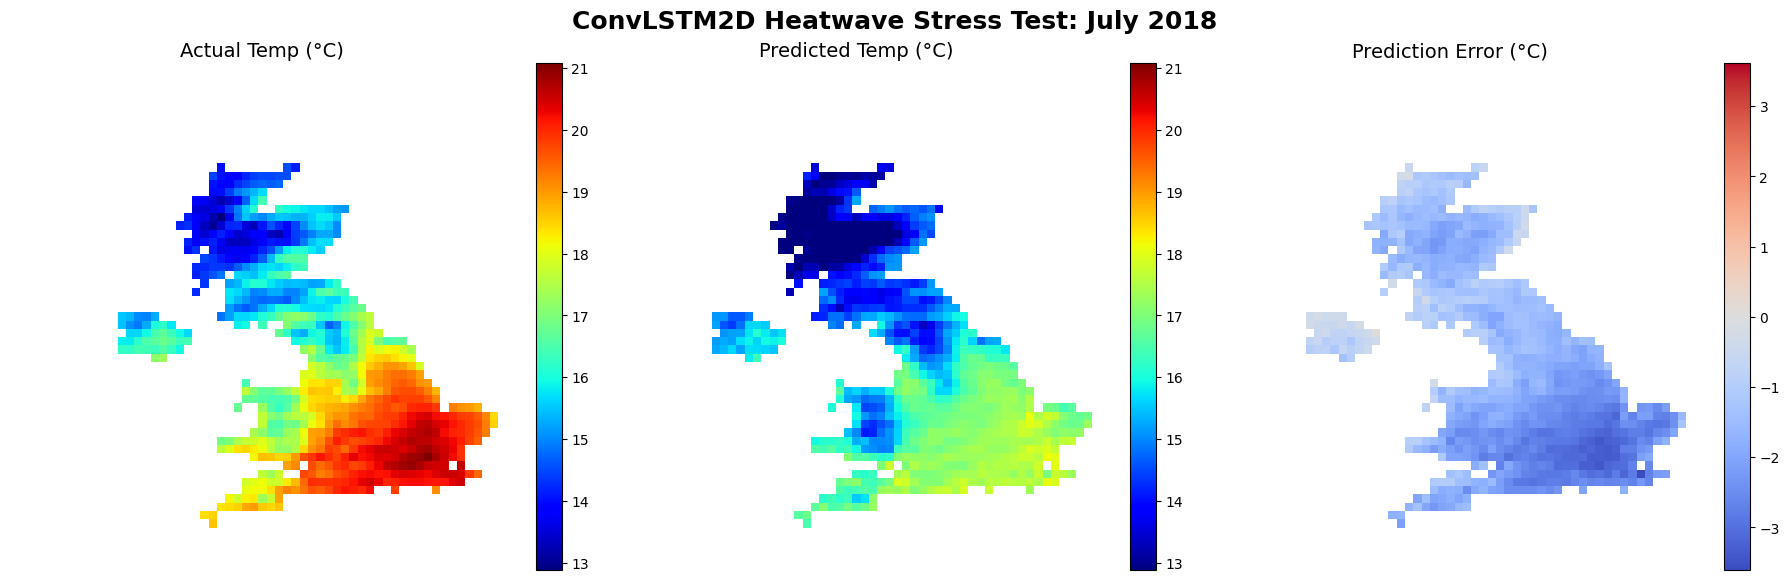

In [13]:
# ==============================================================================
# 9. PLOTTING THE HEATWAVE  
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(f'ConvLSTM2D Heatwave Stress Test: {hottest_date}', fontsize=18, fontweight='bold', y=0.98)

# Map 1: Actual Temperature 
im1 = axes[0].imshow(actual_heatwave, cmap='jet', origin='upper')
axes[0].set_title(f'Actual Temp (°C)', fontsize=14)
axes[0].axis('off')
fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

# Map 2: Predicted Temperature
im2 = axes[1].imshow(predicted_heatwave, cmap='jet', origin='upper', vmin=np.nanmin(actual_heatwave), vmax=np.nanmax(actual_heatwave))
axes[1].set_title(f'Predicted Temp (°C)', fontsize=14)
axes[1].axis('off')
fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

# Map 3: The Difference (Error)
max_error = np.nanmax(np.abs(difference_map))
im3 = axes[2].imshow(difference_map, cmap='coolwarm', origin='upper', vmin=-max_error, vmax=max_error)
axes[2].set_title(f'Prediction Error (°C)', fontsize=14)
axes[2].axis('off')
fig.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [20]:
# ==============================================================================
# 10. PRINTING EXTREME EVENT NUMERICAL METRICS
# ==============================================================================
print(f"\n{'='*80}\n   HEATWAVE STRESS TEST METRICS: {hottest_date}\n{'='*80}")

# Calculate metrics ignoring NaNs (the masked ocean)
hw_mae = np.nanmean(np.abs(difference_map))
hw_rmse = np.sqrt(np.nanmean(difference_map**2))

# Find the absolute worst pixel errors
max_overestimate = np.nanmax(difference_map)
max_underestimate = np.nanmin(difference_map)

# Compare the overall UK spatial averages for that day/month
actual_mean_temp = np.nanmean(actual_heatwave)
pred_mean_temp = np.nanmean(predicted_heatwave)

print(f" > UK Spatial Average (Actual)    : {actual_mean_temp:.2f} °C")
print(f" > UK Spatial Average (Predicted) : {pred_mean_temp:.2f} °C")
print(f" > Heatwave MAE                   : {hw_mae:.2f} °C")
print(f" > Heatwave RMSE                  : {hw_rmse:.2f} °C")
print(f" > Worst Overestimation (Pixel)   : +{max_overestimate:.2f} °C")
print(f" > Worst Underestimation (Pixel)  : {max_underestimate:.2f} °C")


   HEATWAVE STRESS TEST METRICS: July 2018
 > UK Spatial Average (Actual)    : 17.31 °C
 > UK Spatial Average (Predicted) : 15.48 °C
 > Heatwave MAE                   : 1.83 °C
 > Heatwave RMSE                  : 1.97 °C
 > Worst Overestimation (Pixel)   : +0.06 °C
 > Worst Underestimation (Pixel)  : -3.62 °C
